# Libraries

In [276]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# Font

In [277]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Functions

In [ ]:
def gaussian(x, amp, center, fwhm):
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return amp * np.exp(-(x - center)**2 / (2 * sigma**2))

def read_spectrum(filename):

    velocities = []
    intensities = []

    with open(filename, 'r') as f:

        for line in f:

            line = line.strip()

            # Skip comment/header lines
            if line.startswith('%') or len(line) == 0:
                continue

            parts = line.split()

            # Only keep valid numeric rows
            if len(parts) >= 2:

                try:
                    v = float(parts[0])
                    t = float(parts[1])

                    velocities.append(v)
                    intensities.append(t)

                except ValueError:
                    pass

    return np.array(velocities), np.array(intensities)

def read_gaussfit(filename):

    gaussians = []

    with open(filename, 'r') as f:

        for line in f:

            line = line.strip()

            if len(line) == 0:
                continue

            # Extract numbers before parentheses
            numbers = re.findall(r'([-+]?\d*\.\d+|\d+)\s*\(', line)

            if len(numbers) >= 3:

                amp = float(numbers[0])
                center = float(numbers[1])
                fwhm = float(numbers[2])

                gaussians.append((amp, center, fwhm))

    return gaussians



# Read Files

In [ ]:
folder = "/Users/ivarismartinez/Desktop/Astro_Project_2"


spectrum_files = sorted(
    glob.glob(os.path.join(folder, "spectrum_l=*_b=*.txt"))
)

spectrum_files = [f for f in spectrum_files if not f.endswith(".gaussfit")]

n_files = len(spectrum_files)

ncols = 2
nrows = int(np.ceil(n_files / ncols))


# Plot Spectra

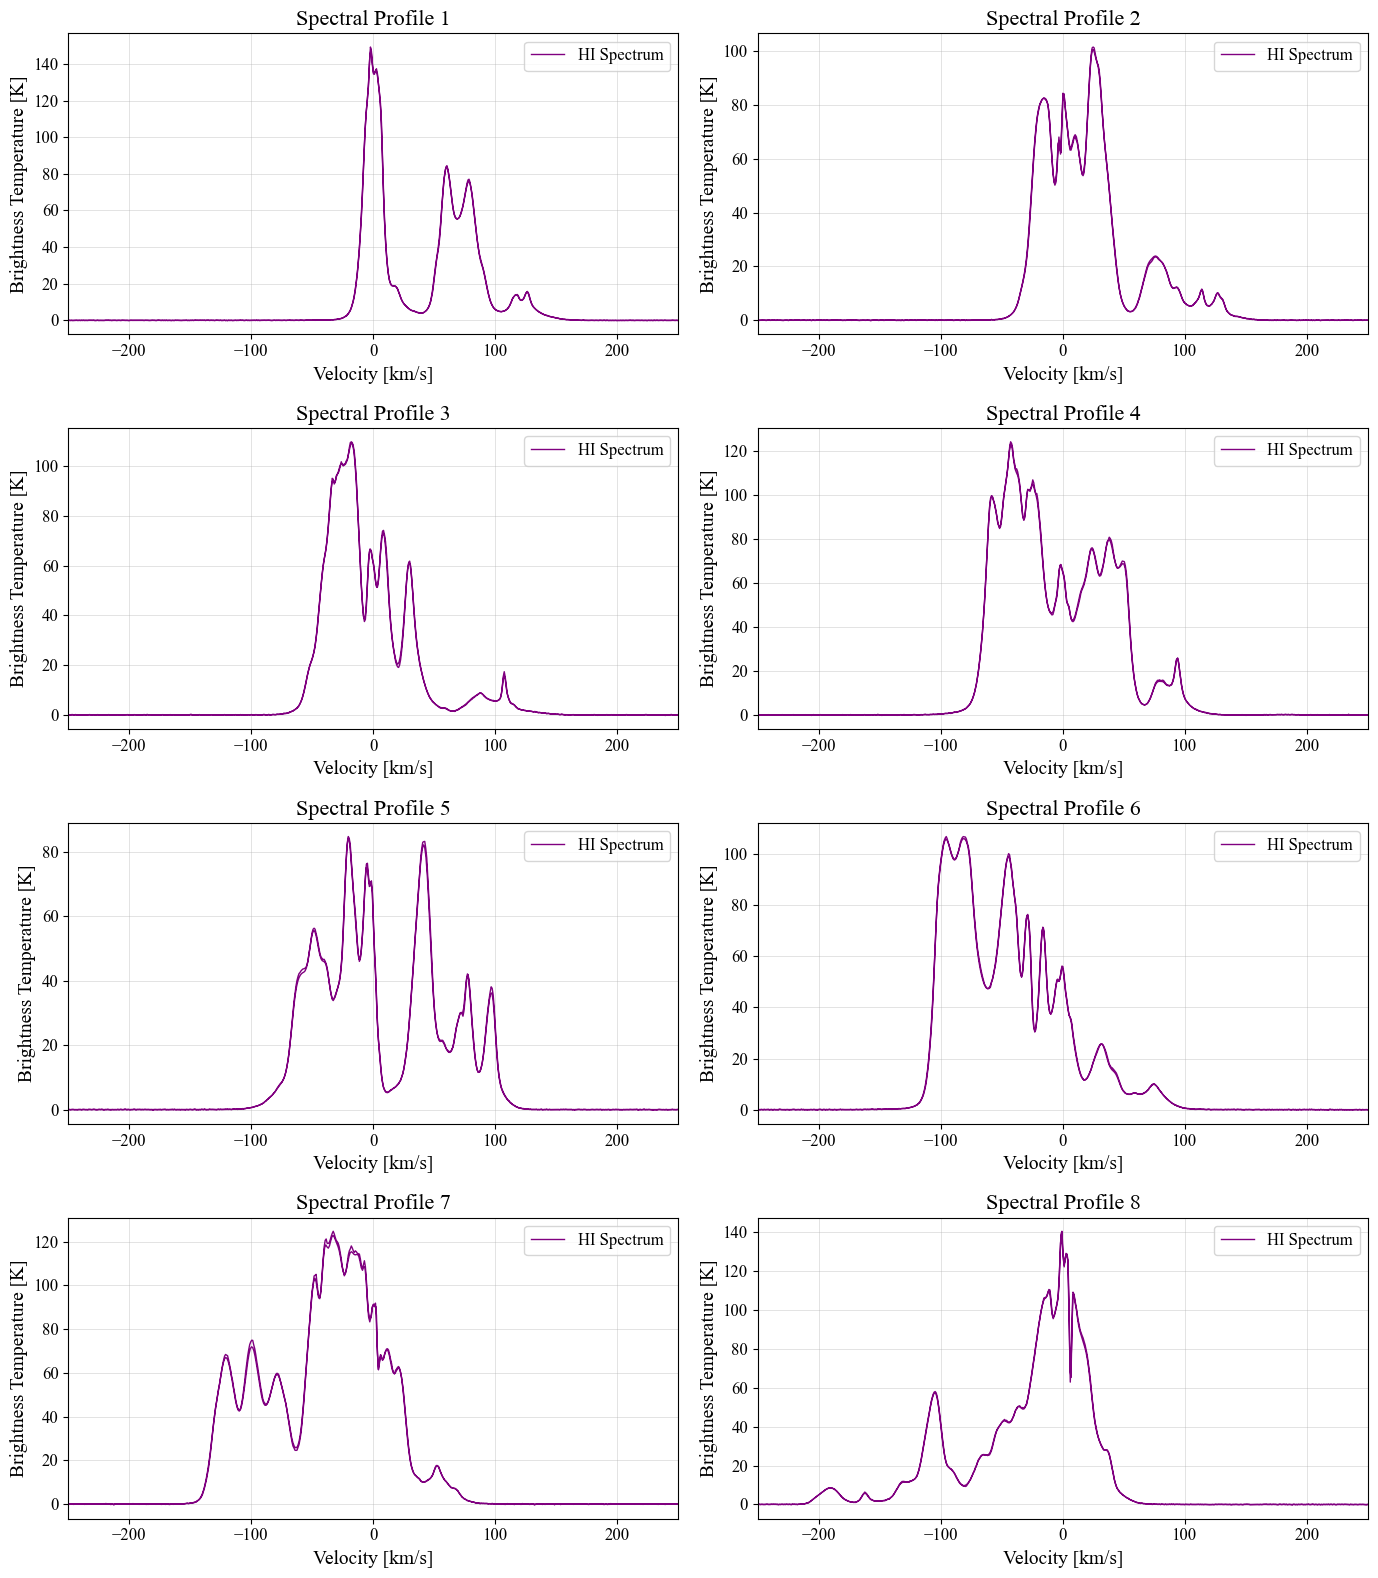


Saved figure to:
/Users/ivarismartinez/Desktop/Astro_Project_2/HI_spectra.pdf


In [280]:
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 4 * nrows)
)

axes = np.array(axes).flatten()

for i, spectrum_path in enumerate(spectrum_files):

    ax = axes[i]

    fit_path = spectrum_path + ".gaussfit"

    velocity, intensity = read_spectrum(spectrum_path)

    ax.plot(
        velocity,
        intensity,
        linewidth=1,
        color='purple',
        label='HI Spectrum'
    )

    filename = os.path.basename(spectrum_path)

    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

    ax.set_xlim(-250, 250)

    # ax.set_title(filename.replace(".txt", ""))
    ax.set_title("Spectral Profile " + str(1 + i))

    ax.set_xlabel("Velocity [km/s]")
    ax.set_ylabel("Brightness Temperature [K]")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

output_file = os.path.join(folder, "HI_spectra.pdf")

plt.savefig(output_file, dpi=300)

plt.show()

print(f"\nSaved figure to:\n{output_file}")

# Plot Spectra With Gaussians

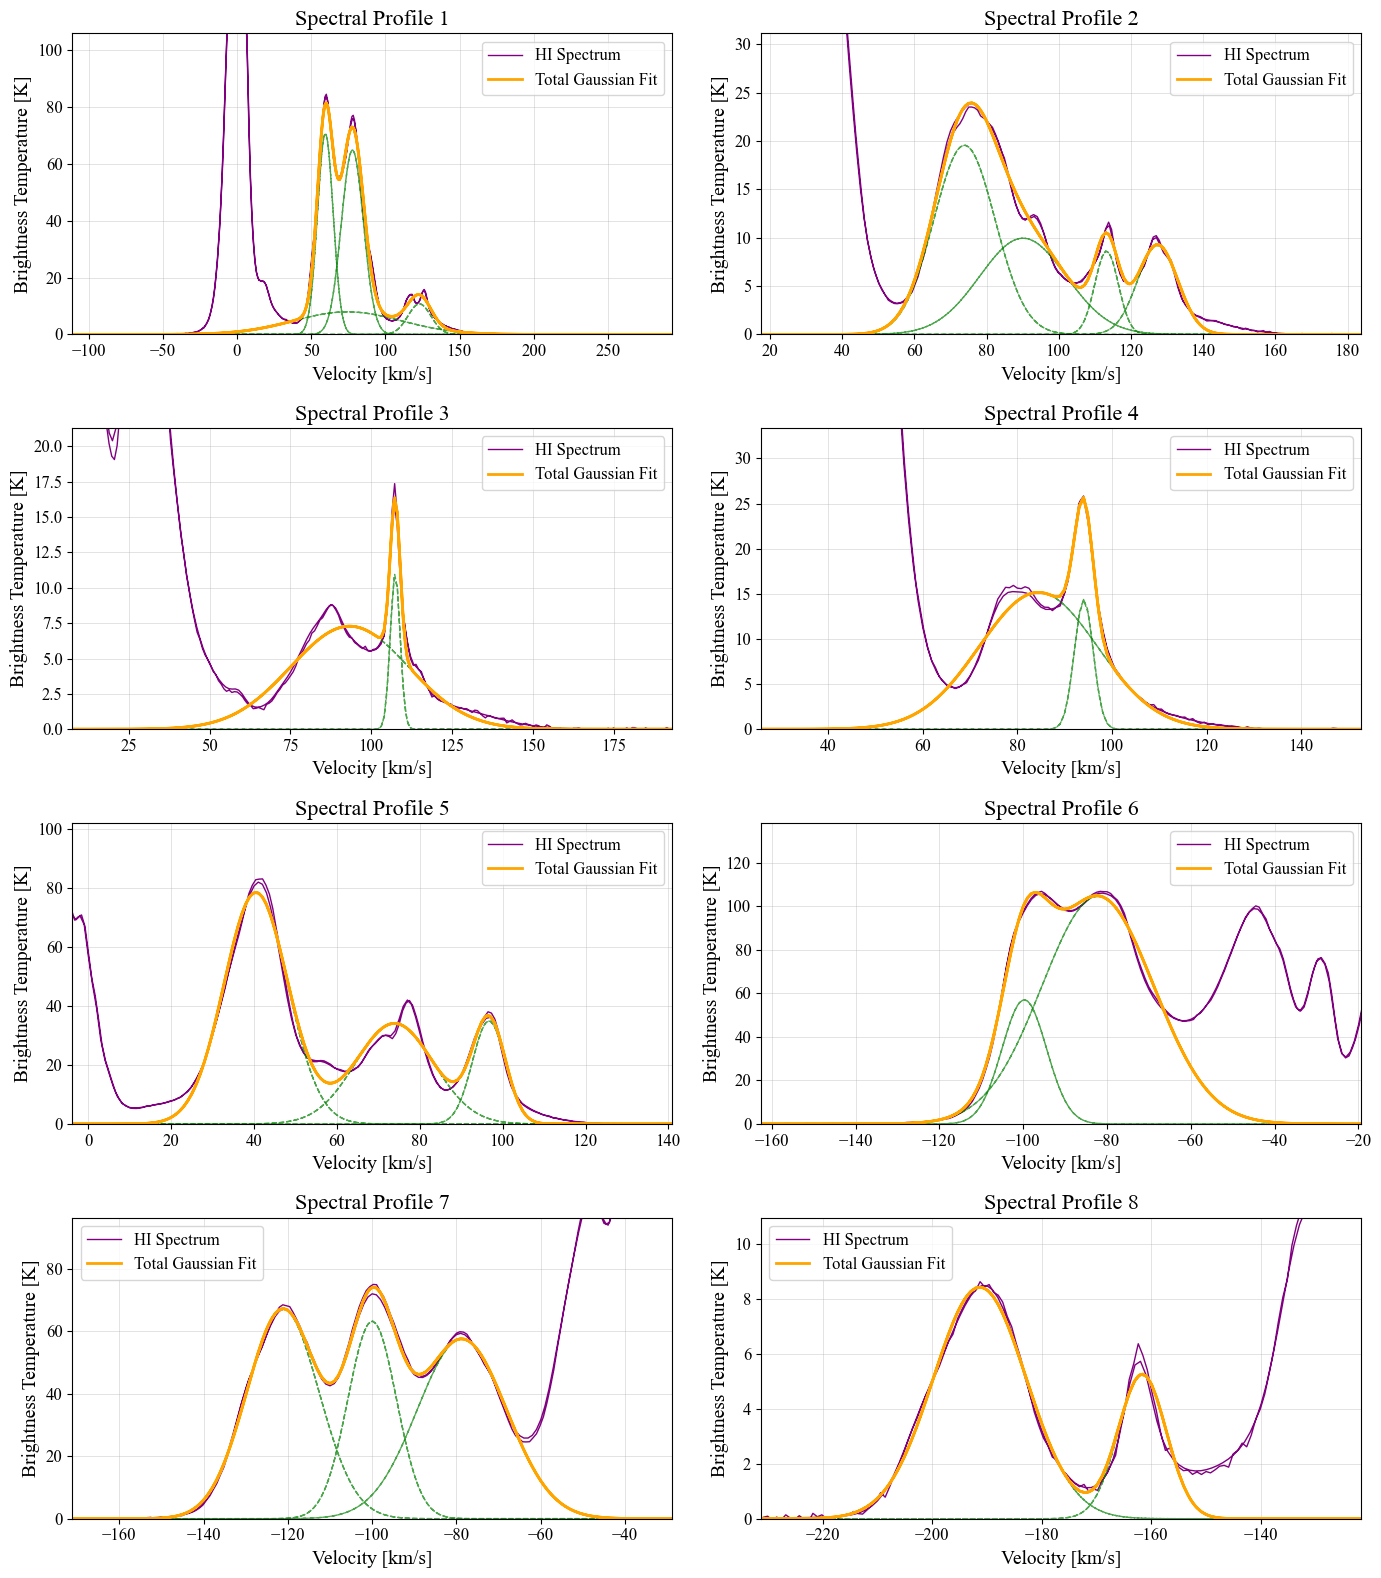

In [281]:
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 4 * nrows)
)

axes = np.array(axes).flatten()

for i, spectrum_path in enumerate(spectrum_files):

    ax = axes[i]

    fit_path = spectrum_path + ".gaussfit"

    velocity, intensity = read_spectrum(spectrum_path)

    ax.plot(
        velocity,
        intensity,
        linewidth=1,
        color='purple',
        label='HI Spectrum'
    )

    if os.path.exists(fit_path):

        gaussians = read_gaussfit(fit_path)

        total_fit = np.zeros_like(velocity)

        # Plot individual gaussians
        for j, (amp, center, fwhm) in enumerate(gaussians):

            g = gaussian(velocity, amp, center, fwhm)

            total_fit += g

            ax.plot(
                velocity,
                g,
                linestyle='--',
                color = 'green',
                linewidth=1,
                alpha=0.7
            )

        # Plot total fit
        ax.plot(
            velocity,
            total_fit,
            color='orange',
            linewidth=2,
            label='Total Gaussian Fit'
        )

        # Determine plotting range from fitted components
        centers = [g[1] for g in gaussians]
        fwhms  = [g[2] for g in gaussians]

        xmin = min(centers) - 2 * max(fwhms)
        xmax = max(centers) + 2 * max(fwhms)

        ax.set_xlim(xmin, xmax)

        # Use fitted model for y scaling
        ymax = np.max(total_fit)

        ax.set_ylim(0, ymax * 1.3)

    else:
        print(f"Missing fit file: {fit_path}")

    filename = os.path.basename(spectrum_path)

    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

    ax.set_title("Spectral Profile " + str(1 + i))

    ax.set_xlabel("Velocity [km/s]")
    ax.set_ylabel("Brightness Temperature [K]")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

output_file = os.path.join(folder, "HI_spectra_gaussian_fits.pdf")
plt.savefig(output_file, dpi=300)

plt.show()

# Calculate Rotational Velocity Using Tangent Method

In [ ]:
spectra = [1,2,3,4,5,6,7,8]

vr = [
    122.95,
    127.38,
    107.36,
    94.04,
    96.68,
    -99.74,
    -121.18,
    -191.31
]

vr_err = [
    0.33,
    0.14,
    0.06,
    0.06,
    0.15,
    0.07,
    0.05,
    0.07
]

l_deg = [
    277.0,
    291.0,
    301.0,
    311.0,
    318.0,
    328.0,
    339.0,
    350.0
]

# R values [kpc]
R = [
    7.94,
    7.47,
    6.86,
    6.04,
    5.35,
    4.24,
    2.87,
    1.39
]

Theta = []
Theta_err = []

for i in range(len(vr)):

    # Convert longitude to radians
    l_rad = np.radians(l_deg[i])

    # Compute Theta(R)
    theta_val = np.abs(vr[i]) + 220 * np.abs(np.sin(l_rad))

    # Save values into lists
    Theta.append(theta_val)

    # Error propagation
    Theta_err.append(vr_err[i])

for i in range(len(spectra)):
    print(
        f"Spectrum {spectra[i]}: "
        f"R = {R[i]:.2f} kpc, "
        f"Theta = {Theta[i]:.2f} +/- {Theta_err[i]:.2f} km/s"
    )


Spectrum 1: R = 7.94 kpc, Theta = 341.31 +/- 0.33 km/s
Spectrum 2: R = 7.47 kpc, Theta = 332.77 +/- 0.14 km/s
Spectrum 3: R = 6.86 kpc, Theta = 295.94 +/- 0.06 km/s
Spectrum 4: R = 6.04 kpc, Theta = 260.08 +/- 0.06 km/s
Spectrum 5: R = 5.35 kpc, Theta = 243.89 +/- 0.15 km/s
Spectrum 6: R = 4.24 kpc, Theta = 216.32 +/- 0.07 km/s
Spectrum 7: R = 2.87 kpc, Theta = 200.02 +/- 0.05 km/s
Spectrum 8: R = 1.39 kpc, Theta = 229.51 +/- 0.07 km/s


# Plotting Inner Galactic Rotation Curve With HI Profile Search

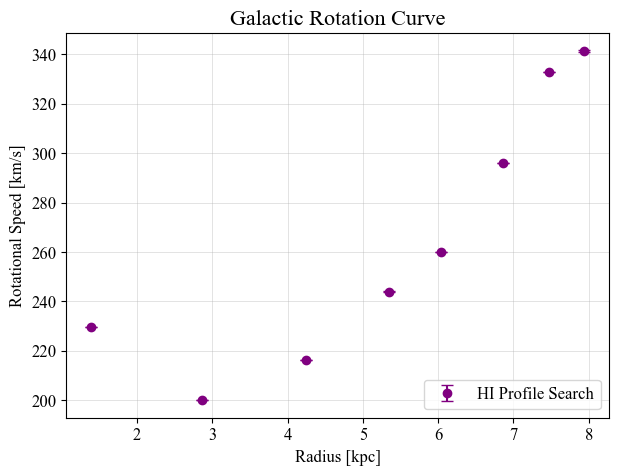

In [283]:
plt.figure(figsize=(7,5))

plt.errorbar(
    R,
    Theta,
    yerr=Theta_err,
    color='purple',
    fmt='o',
    capsize=4,
    markersize=6,
    label='HI Profile Search'
)

plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

plt.xlabel('Radius [kpc]', fontsize=12)
plt.ylabel('Rotational Speed [km/s]', fontsize=12)

plt.title('Galactic Rotation Curve')

plt.legend(loc='lower right')

output_file = os.path.join(folder, "HI_Galactic_Rotation_Curve.pdf")
plt.savefig(output_file, dpi=300)

plt.show()

# Read WISE data

In [284]:
with open("Table2.txt") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if line.startswith("G"):
        print("First data line at:", i)
        break



First data line at: 49


In [285]:
colspecs2 = [
    (0,15),     # WISE
    (16,17),    # Class
    (18,25),    # WGLON
    (26,33),    # WGLAT
    (34,38),    # R
    (39,75),    # HIIName
    (76,112),   # Mem
    (113,120),  # HGLON
    (121,128),  # HGLAT
    (129,153),  # VLSR
    (154,170),  # eVLSR
    (171,191),  # DelV
    (192,208),  # eDelV
    (209,211)   # Ref
]

table2 = pd.read_fwf(
    "Table2.txt",
    colspecs=colspecs2,
    names=[
        "WISE","Class","WGLON","WGLAT","R","HIIName",
        "Mem","HGLON","HGLAT","VLSR","eVLSR",
        "DelV","eDelV","Ref"
    ],
    skiprows=49  
)

table2 = table2.dropna(subset=["WGLON", "VLSR"])

print(table2.head())
print(table2.columns)
print(len(table2))


               WISE Class  WGLON  WGLAT    R          HIIName  Mem  HGLON  \
0   G000.003+00.127     K  0.004  0.128  206              S17  NaN  0.020   
12  G000.120-00.556     K  0.120 -0.556  360              S19  NaN  0.111   
27  G000.279-00.482     K  0.279 -0.482   60  G000.284-00.478  NaN  0.284   
29  G000.314-00.194     K  0.314 -0.194   26              S20  NaN  0.335   
30  G000.314-00.205     K  0.315 -0.204   42              S20  NaN  0.335   

    HGLAT  VLSR eVLSR  DelV eDelV  Ref  
0   0.126  -5.5   1.0  36.3   0.7  7.0  
12 -0.562  11.6   2.4  19.7   0.3  7.0  
27 -0.478  20.0   NaN  29.0   NaN  6.0  
29 -0.194   9.6   0.5  27.2   0.7  7.0  
30 -0.194   9.6   0.5  27.2   0.7  7.0  
Index(['WISE', 'Class', 'WGLON', 'WGLAT', 'R', 'HIIName', 'Mem', 'HGLON',
       'HGLAT', 'VLSR', 'eVLSR', 'DelV', 'eDelV', 'Ref'],
      dtype='object')
1523


In [286]:
colspecs6 = [
    (0,15),    # WISE
    (16,19),   # Near
    (20,24),   # Far
    (25,28),   # Tan
    (29,34),   # RGal
    (35,41),   # VT
    (41,42),   # KDAR
    (43,47),   # Dis
    (48,52),   # e_Dis
    (53,56),   # Azi
    (57,61),   # z
    (62,80),   # Method
    (81,83)    # Ref
]

table6 = pd.read_fwf(
    "Table6.txt",
    colspecs=colspecs6,
    names=[
        "WISE","Near","Far","Tan","RGal","VT",
        "KDAR","Dis","e_Dis","Azi","z",
        "Method","Ref"
    ],
    skiprows=77
)

table6 = table6.dropna(subset=["RGal"])

print(table6.head())
print(table6.columns)
print(len(table6))

                WISE  Near  Far  Tan  RGal  VT KDAR  Dis  e_Dis  Azi     z  \
109  G000.649-00.080   NaN  NaN  NaN   0.7 NaN  NaN  7.8    0.9  NaN -10.0   
125  G000.729-00.103   NaN  NaN  NaN   0.1 NaN  NaN  8.5    NaN    9 -15.0   
541  G009.598+00.199   NaN  NaN  NaN   3.5 NaN  NaN  5.2    0.6    4  17.0   
543  G009.612+00.205   NaN  NaN  NaN   3.5 NaN  NaN  5.2    0.6    4  18.0   
544  G009.613+00.200   NaN  NaN  NaN   3.5 NaN  NaN  5.2    0.6    4  17.0   

          Method   Ref  
109      arallax  24.0  
125  uclear Disk   NaN  
541      arallax  27.0  
543      arallax  27.0  
544      arallax  27.0  
Index(['WISE', 'Near', 'Far', 'Tan', 'RGal', 'VT', 'KDAR', 'Dis', 'e_Dis',
       'Azi', 'z', 'Method', 'Ref'],
      dtype='object')
2304


In [ ]:
# Convert columns to numeric
table2["WGLON"] = pd.to_numeric(table2["WGLON"], errors='coerce')

# VLSR sometimes contains semicolons
table2["VLSR"] = (
    table2["VLSR"]
    .astype(str)
    .str.split(";")
    .str[0]
)

table2["VLSR"] = pd.to_numeric(table2["VLSR"], errors='coerce')
table6["RGal"] = pd.to_numeric(table6["RGal"], errors='coerce')
merged = pd.merge(table2, table6, on="WISE")


In [288]:
# Inner Galaxy
inner = merged[
    (merged["WGLON"] < 90) |
    (merged["WGLON"] > 270)
]

# Optional:
# choose only sources with reasonable values
inner = inner.dropna(subset=["VLSR", "RGal"])

print(inner)

# Outer Galaxy
outer = merged[
    (merged["WGLON"] > 90) &
    (merged["WGLON"] < 270)
]

# Optional:
# choose only sources with reasonable values
outer = outer.dropna(subset=["VLSR", "RGal"])

print(outer)



                 WISE Class    WGLON  WGLAT    R                  HIIName  \
0     G000.649-00.080     K    0.649 -0.080   95  G000.656-00.058; Sgr B2   
1     G000.729-00.103     K    0.729 -0.103   72          G000.729-00.103   
2     G009.598+00.199     K    9.599  0.199   34          G009.615+00.198   
3     G009.612+00.205     K    9.613  0.206   34          G009.615+00.198   
4     G009.613+00.200     K    9.614  0.200   86          G009.615+00.198   
...               ...   ...      ...    ...  ...                      ...   
1125  G358.720+00.010     K  358.720  0.011   42          G358.720+00.011   
1126  G358.787+00.061     K  358.787  0.062   60          G358.797+00.058   
1127  G358.827+00.085     K  358.827  0.085   42          G358.827+00.085   
1128  G358.982-00.030     K  358.982 -0.030  115          G358.974-00.021   
1129  G359.161-00.038     K  359.161 -0.037   40          G359.159-00.038   

                          Mem    HGLON  HGLAT   VLSR  ... Tan RGal  VT  KDA

# Calculate Inner and Outer Rotational Velocities with WISE

In [ ]:
R_inner = []
Theta_inner = []
Theta_err_inner = []

for i in range(len(inner)):

    # Extract values
    l_deg = inner.iloc[i]["WGLON"]
    vr = inner.iloc[i]["VLSR"]
    vr_err = inner.iloc[i]["eVLSR"]   # <-- add this if available

    # Convert to radians
    l_rad = np.radians(l_deg)

    # Avoid bad geometry
    if np.abs(np.sin(l_rad)) < 0.1:
        continue

    # Compute radius (tangent point)
    Rgal = 8 * np.abs(np.sin(l_rad))

    # Compute rotation velocity (general form)
    theta = (np.abs(vr / np.sin(l_rad)) + 220) * (Rgal / 8)

    # Store values
    R_inner.append(Rgal)
    Theta_inner.append(theta)

    # Error propagation (same idea as your first code)
    Theta_err_inner.append(vr_err)

In [290]:
R_outer = []
Theta_outer = []

for i in range(len(outer)):

    l_deg = outer.iloc[i]["WGLON"]
    vr = outer.iloc[i]["VLSR"]
    Rgal = outer.iloc[i]["RGal"]

    l_rad = np.radians(l_deg)

    # Avoid bad sin(l)
    if np.abs(np.sin(l_rad)) < 0.1:
        continue

    theta = ((vr / np.sin(l_rad)) + 220) * (Rgal / 8)

    R_outer.append(Rgal)
    Theta_outer.append(theta)

print(R_outer)
print(Theta_outer)


[13.3, 12.1, 8.7, 12.1, 10.5, 16.1, 13.6, 13.6, 11.2, 11.1, 12.6, 10.5, 10.5, 11.9, 11.7, 12.2, 11.4, 11.4, 11.4, 11.4, 11.6, 11.4, 9.8, 12.7, 11.0, 11.0, 11.4, 10.4, 11.5, 13.1, 13.1, 11.0, 11.2, 12.1, 11.2, 10.6, 12.3, 10.3, 13.3, 13.4, 11.7, 9.9, 9.9, 11.9, 12.4, 12.5, 13.0, 12.8, 10.0, 11.4, 12.2, 11.4, 11.2, 12.4, 12.5, 16.9, 14.1, 15.7, 11.8, 14.7, 10.6, 10.1, 13.7, 13.0, 8.9, 8.9, 8.9, 14.4, 12.7, 10.7, 14.4, 11.2, 13.5, 11.9, 13.3, 9.6, 11.1, 10.9, 10.9, 12.1, 10.4, 12.5, 9.3, 12.9]
[242.0591452855688, 240.3355247029887, 238.37904669032943, 240.3674717064717, 240.03766948293313, 242.5083135834446, 242.30885945532893, 242.30461047392672, 238.92275806749686, 238.7815682645233, 241.5300633803382, 239.33209019889742, 239.28557155171853, 239.72431252862407, 239.9672172294572, 240.53034379210976, 239.6099192793503, 239.60772971276495, 239.6051013187215, 239.60203359839014, 239.17359168586938, 239.93917766923607, 189.4179469004656, 240.99188590801987, 240.41798222012383, 238.431198470

# Plotting Galactic Rotational Curve with WISE

Original legend order: ['WISE HII Inner Regions', 'WISE HII Outer Regions', 'HI Profile Search']


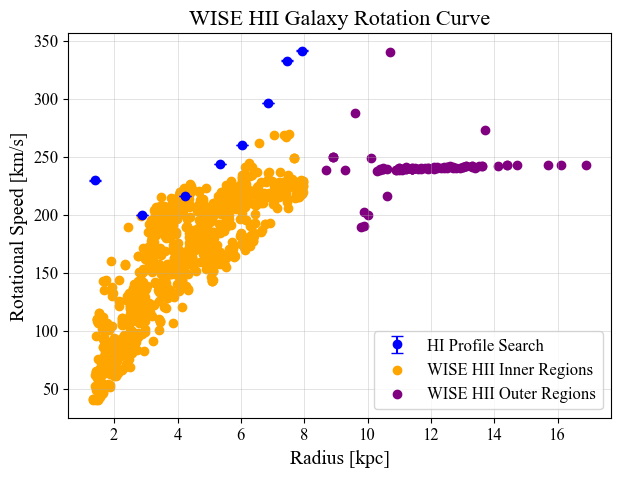

In [294]:
plt.figure(figsize=(7,5))

plt.scatter(
    R_inner,
    Theta_inner,
    color='orange',
    label='WISE HII Inner Regions'
)

plt.scatter(
    R_outer,
    Theta_outer,
    color='purple',
    label='WISE HII Outer Regions'
)

plt.errorbar(
    R,
    Theta,
    yerr=Theta_err,
    color='blue',
    fmt='o',
    capsize=4,
    markersize=6,
    label='HI Profile Search'
)

plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

plt.xlabel('Radius [kpc]')
plt.ylabel('Rotational Speed [km/s]')

plt.title('WISE HII Galaxy Rotation Curve')

# 1. Get existing handles and labels from the current axes
handles, labels = plt.gca().get_legend_handles_labels()
print("Original legend order:", labels)

# 2. Define your desired order by index (e.g., [2, 0, 1])
order = [2, 0, 1] # Example: swap the first and second items
new_handles = [handles[i] for i in order]
new_labels = [labels[i] for i in order]

# 3. Apply the legend with your custom order and location
plt.legend(new_handles, new_labels, loc='lower right')

output_file = os.path.join(folder, "WISE_HII_Galactic_Rotation_Curve.pdf")
plt.savefig(output_file, dpi=300)

plt.show()

# Plotting Galactic Curve with Keplerian Rotation Curve

Original legend order: ['WISE HII Inner Regions', 'WISE HII Outer Regions', 'Keplerian Rotation Curve', 'HI Profile Search']


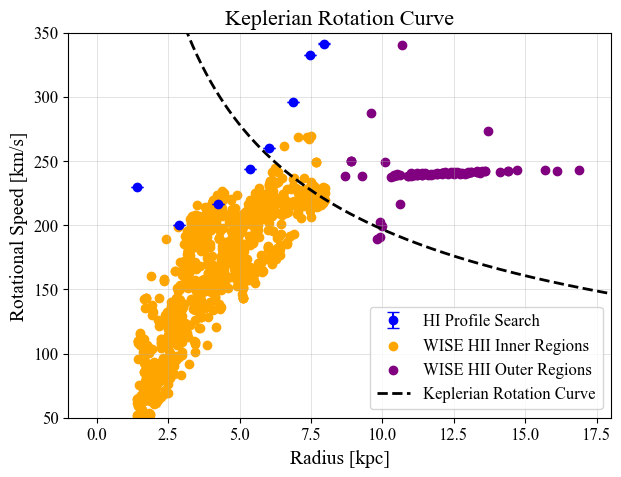

In [298]:
plt.figure(figsize=(7,5))

plt.errorbar(
    R,
    Theta,
    yerr=Theta_err,
    color='blue',
    fmt='o',
    capsize=4,
    markersize=6,
    label='HI Profile Search'
)

plt.scatter(
    R_inner,
    Theta_inner,
    color='orange',
    label='WISE HII Inner Regions'
)

plt.scatter(
    R_outer,
    Theta_outer,
    color='purple',
    label='WISE HII Outer Regions'
)

plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

plt.xlabel('Radius [kpc]')
plt.ylabel('Rotational Speed [km/s]')

plt.title('Keplerian Rotation Curve')

# Create smooth radius values
R_kep = np.linspace(0.5, 20, 500)

# Keplerian rotation curve
Theta_kep = 220 * np.sqrt(8 / R_kep)

# Plot
plt.plot(
    R_kep,
    Theta_kep,
    color='black',
    linewidth=2,
    linestyle='--',
    label='Keplerian Rotation Curve'
)

plt.ylim(50,350)
plt.xlim(-1,18)

# 1. Get existing handles and labels from the current axes
handles, labels = plt.gca().get_legend_handles_labels()
print("Original legend order:", labels)

# 2. Define your desired order by index (e.g., [2, 0, 1])
order = [3, 0, 1, 2] # Example: swap the first and second items
new_handles = [handles[i] for i in order]
new_labels = [labels[i] for i in order]

# 3. Apply the legend with your custom order and location
plt.legend(new_handles, new_labels, loc='lower right')

# plt.legend(loc='lower right')

output_file = os.path.join(folder, "Keplerian_Rotation_Galactic_Rotation_Curve.pdf")
plt.savefig(output_file, dpi=300)

plt.show()

# Read Sofue2013's Data

In [267]:
data = np.loadtxt("sofue2013_rotation_curve.txt", skiprows=1)

r1, dr1, v1, dv1 = data[:, 0], data[:, 1], data[:, 2], data[:, 3]
r2, dr2, v2, dv2 = data[:, 4], data[:, 5], data[:, 6], data[:, 7]

r = np.concatenate([r1, r2])
dr = np.concatenate([dr1, dr2])
v = np.concatenate([v1, v2])
dv = np.concatenate([dv1, dv2])

mask = r <= 18

r = r[mask]
dr = dr[mask]
v = v[mask]
dv = dv[mask]

# Read Sofue2013's Galactic Rotation Curve

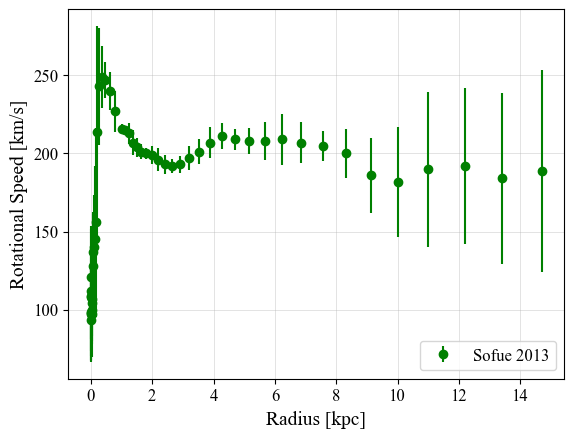

In [268]:
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

plt.errorbar(r, v, yerr=dv, color='green', fmt='o', label='Sofue 2013')

plt.xlabel("Radius [kpc]")
plt.ylabel("Rotational Speed [km/s]")
plt.legend(loc='lower right')

output_file = os.path.join(folder, "Sofue2013_Galactic_Rotation_Curve.pdf")
plt.savefig(output_file, dpi=300)

plt.show()

# Plotting Final Image

Original legend order: ['WISE HII Inner Regions', 'WISE HII Outer Regions', 'Keplerian Rotation Curve', 'HI Profile Search', 'Sofue 2013']


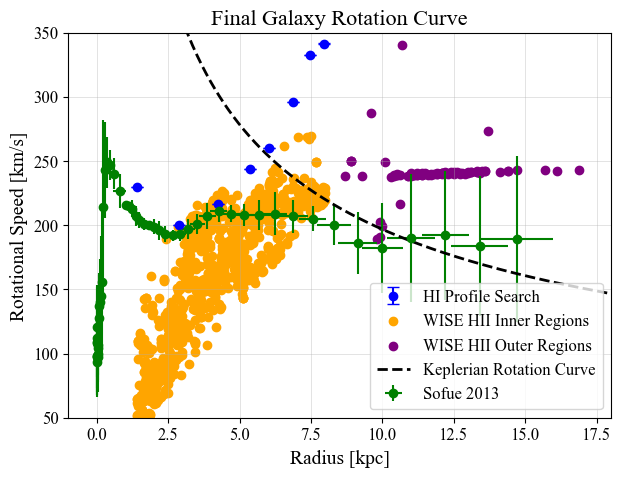

In [297]:
plt.figure(figsize=(7,5))

plt.errorbar(
    R,
    Theta,
    yerr=Theta_err,
    color='blue',
    fmt='o',
    capsize=4,
    markersize=6,
    label='HI Profile Search'
)

plt.scatter(
    R_inner,
    Theta_inner,
    color='orange',
    label='WISE HII Inner Regions'
)

plt.scatter(
    R_outer,
    Theta_outer,
    color='purple',
    label='WISE HII Outer Regions'
)

plt.errorbar(r, v, yerr=dv, xerr=dr, color='green', fmt='o', label='Sofue 2013')


plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

plt.xlabel('Radius [kpc]')
plt.ylabel('Rotational Speed [km/s]')

plt.title('Final Galaxy Rotation Curve')

# Create smooth radius values
R_kep = np.linspace(0.5, 20, 500)

# Keplerian rotation curve
Theta_kep = 220 * np.sqrt(8 / R_kep)

# Plot
plt.plot(
    R_kep,
    Theta_kep,
    color='black',
    linewidth=2,
    linestyle='--',
    label='Keplerian Rotation Curve'
)

plt.ylim(50,350)
plt.xlim(-1,18)

# 1. Get existing handles and labels from the current axes
handles, labels = plt.gca().get_legend_handles_labels()
print("Original legend order:", labels)

# 2. Define your desired order by index (e.g., [2, 0, 1])
order = [3, 0, 1, 2, 4] # Example: swap the first and second items
new_handles = [handles[i] for i in order]
new_labels = [labels[i] for i in order]

# 3. Apply the legend with your custom order and location
plt.legend(new_handles, new_labels, loc='lower right')

output_file = os.path.join(folder, "Final_Plot_Galactic_Rotation_Curve.pdf")
plt.savefig(output_file, dpi=300)

plt.show()